In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import time
import json
import tensorflow as tf
from sklearn.metrics import precision_score, recall_score, f1_score

np.random.seed(42)

os.makedirs('images/eval', exist_ok=True)
os.makedirs('results', exist_ok=True)

EDGE_TYPES = {
    0: 'Horizontal',  1: 'Vertical',
    2: 'Diag BL-TR',  3: 'Diag TL-BR',
    4: 'Corner TL',   5: 'Corner TR',
    6: 'Corner BL',   7: 'Corner BR',
    8: 'T-Top',       9: 'T-Bottom',
    10: 'Cross',      11: 'No Edge'
}
NUM_CLASSES = 12
NO_EDGE     = 11
PATCH_SIZE  = 5
PAD         = PATCH_SIZE // 2

print('Imports done. TF:', tf.__version__)

Imports done. TF: 2.20.0


In [2]:
model = tf.keras.models.load_model('models/edge_cnn_v3_final.keras')
print('Loaded: EdgeCNN v3')
model.summary()

Loaded: EdgeCNN v3


Model: "EdgeCNN_v3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 5, 5, 16)       │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 5, 5, 16)       │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 5, 5, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 5, 5, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 12)             │           780 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 170,918 (667.65 KB)

 Trainable params: 56,940 (222.42 KB)

 Non-trainable params: 96 (384.00 B)

 Optimizer params: 113,882 (444.86 KB)

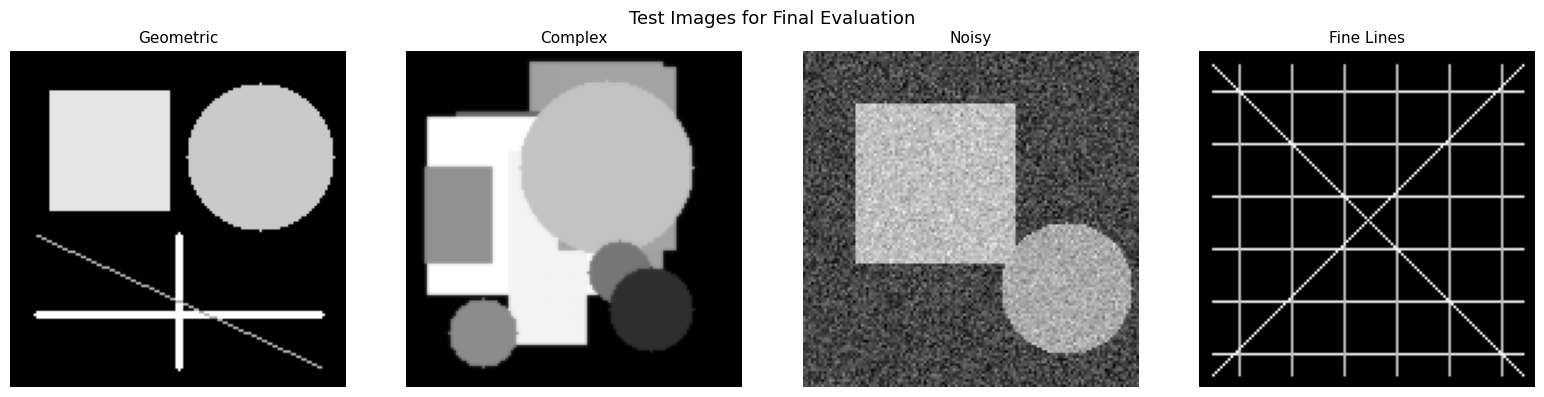

In [3]:
def make_geometric(size=128):
    img = np.full((size, size), 30, dtype=np.uint8)
    cv2.rectangle(img, (15, 15), (60, 60), 200, -1)
    cv2.circle(img, (95, 40), 28, 180, -1)
    cv2.line(img, (10, 100), (118, 100), 220, 2)
    cv2.line(img, (64, 70), (64, 120), 220, 2)
    cv2.line(img, (10, 70), (118, 120), 160, 1)
    return img

def make_complex(size=128):
    np.random.seed(7)
    img = np.full((size, size), 50, dtype=np.uint8)
    for _ in range(6):
        x1, y1 = np.random.randint(0, size//2, 2)
        x2 = min(x1 + np.random.randint(25, 80), size - 1)
        y2 = min(y1 + np.random.randint(25, 80), size - 1)
        cv2.rectangle(img, (x1, y1), (x2, y2), int(np.random.randint(100, 240)), -1)
    for _ in range(4):
        cx, cy = np.random.randint(20, size-20, 2)
        cv2.circle(img, (int(cx), int(cy)), int(np.random.randint(10, 35)),
                   int(np.random.randint(80, 220)), -1)
    return cv2.GaussianBlur(img, (3, 3), 0.5)

def make_noisy(size=128):
    np.random.seed(11)
    img = np.random.randint(40, 100, (size, size), dtype=np.uint8)
    cv2.rectangle(img, (20, 20), (80, 80), 190, -1)
    cv2.circle(img, (100, 90), 25, 170, -1)
    noise = np.random.normal(0, 18, img.shape).astype(np.int16)
    return np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

def make_finelines(size=128):
    img = np.full((size, size), 30, dtype=np.uint8)
    for y in range(15, size, 20):
        cv2.line(img, (5, y), (123, y), 200, 1)
    for x in range(15, size, 20):
        cv2.line(img, (x, 5), (x, 123), 170, 1)
    cv2.line(img, (5, 5),   (123, 123), 220, 1)
    cv2.line(img, (5, 123), (123, 5),   220, 1)
    return img


TEST_IMAGES = {
    'Geometric':  make_geometric(),
    'Complex':    make_complex(),
    'Noisy':      make_noisy(),
    'Fine Lines': make_finelines(),
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (name, img) in zip(axes, TEST_IMAGES.items()):
    ax.imshow(img, cmap='gray')
    ax.set_title(name, fontsize=11)
    ax.axis('off')
plt.suptitle('Test Images for Final Evaluation', fontsize=13)
plt.tight_layout()
plt.savefig('images/eval/test_images.png', dpi=120)
plt.show()

In [6]:
import cv2
from tensorflow.python.feature_column import feature_column_v2
def cnn_edge_map(gray_img, model, batch_size=512):
    """Run sliding-window inference and return edge map, type map, and confidence map."""
    H, W   = gray_img.shape
    padded = cv2.copyMakeBorder(gray_img, PAD, PAD, PAD, PAD, cv2.BORDER_REFLECT)

    # Collect all patches
    patches = []
    for r in range(H):
        for c in range(W):
            p = padded[r:r+PATCH_SIZE, c:c+PATCH_SIZE].astype(np.float32) / 255.0
            patches.append(p)

    patches = np.array(patches).reshape(-1, PATCH_SIZE, PATCH_SIZE, 1)

    # Predict in batches
    preds        = model.predict(patches, batch_size=batch_size, verbose=0)
    pred_classes = np.argmax(preds, axis=1)
    confidences  = preds.max(axis=1)

    type_map = pred_classes.reshape(H, W)
    conf_map = confidences.reshape(H, W)
    edge_map = np.where(type_map != NO_EDGE, 255, 0).astype(np.uint8)

    return edge_map, type_map, conf_map


def canny_edge_map(gray_img):
    return cv2.Canny(gray_img, 50, 150)


def sobel_edge_map(gray_img, threshold=50):
    gx  = cv2.Sobel(gray_img, cv2.CV_64F, 1, 0, ksize=3)
    gy  = cv2.Sobel(gray_img, cv2.CV_64F, 0, 1, ksize=3)
    mag = np.clip(np.sqrt(gx**2 + gy**2), 0, 255).astype(np.uint8)
    _, binary = cv2.threshold(mag, threshold, 255, cv2.THRESH_BINARY)
    return binary


# Quick test
print('Testing inference on first image...')
t0 = time.time()
sample_edge, _, _ = cnn_edge_map(list(TEST_IMAGES.values())[0], model)
print(f'Done in {time.time()-t0:.2f}s')

Testing inference on first image...
Done in 0.19s


In [7]:
all_results = {}

for name, img in TEST_IMAGES.items():
    print(f'Processing: {name}...')
    cnn_map, type_map, conf_map = cnn_edge_map(img, model)
    all_results[name] = {
        'original': img,
        'cnn':      cnn_map,
        'type_map': type_map,
        'conf_map': conf_map,
        'canny':    canny_edge_map(img),
        'sobel':    sobel_edge_map(img),
    }
    print(f'  CNN edge pixels: {(cnn_map > 0).sum()}')

print('All images processed.')

Processing: Geometric...
  CNN edge pixels: 5295
Processing: Complex...
  CNN edge pixels: 8549
Processing: Noisy...
  CNN edge pixels: 5780
Processing: Fine Lines...
  CNN edge pixels: 1827
All images processed.


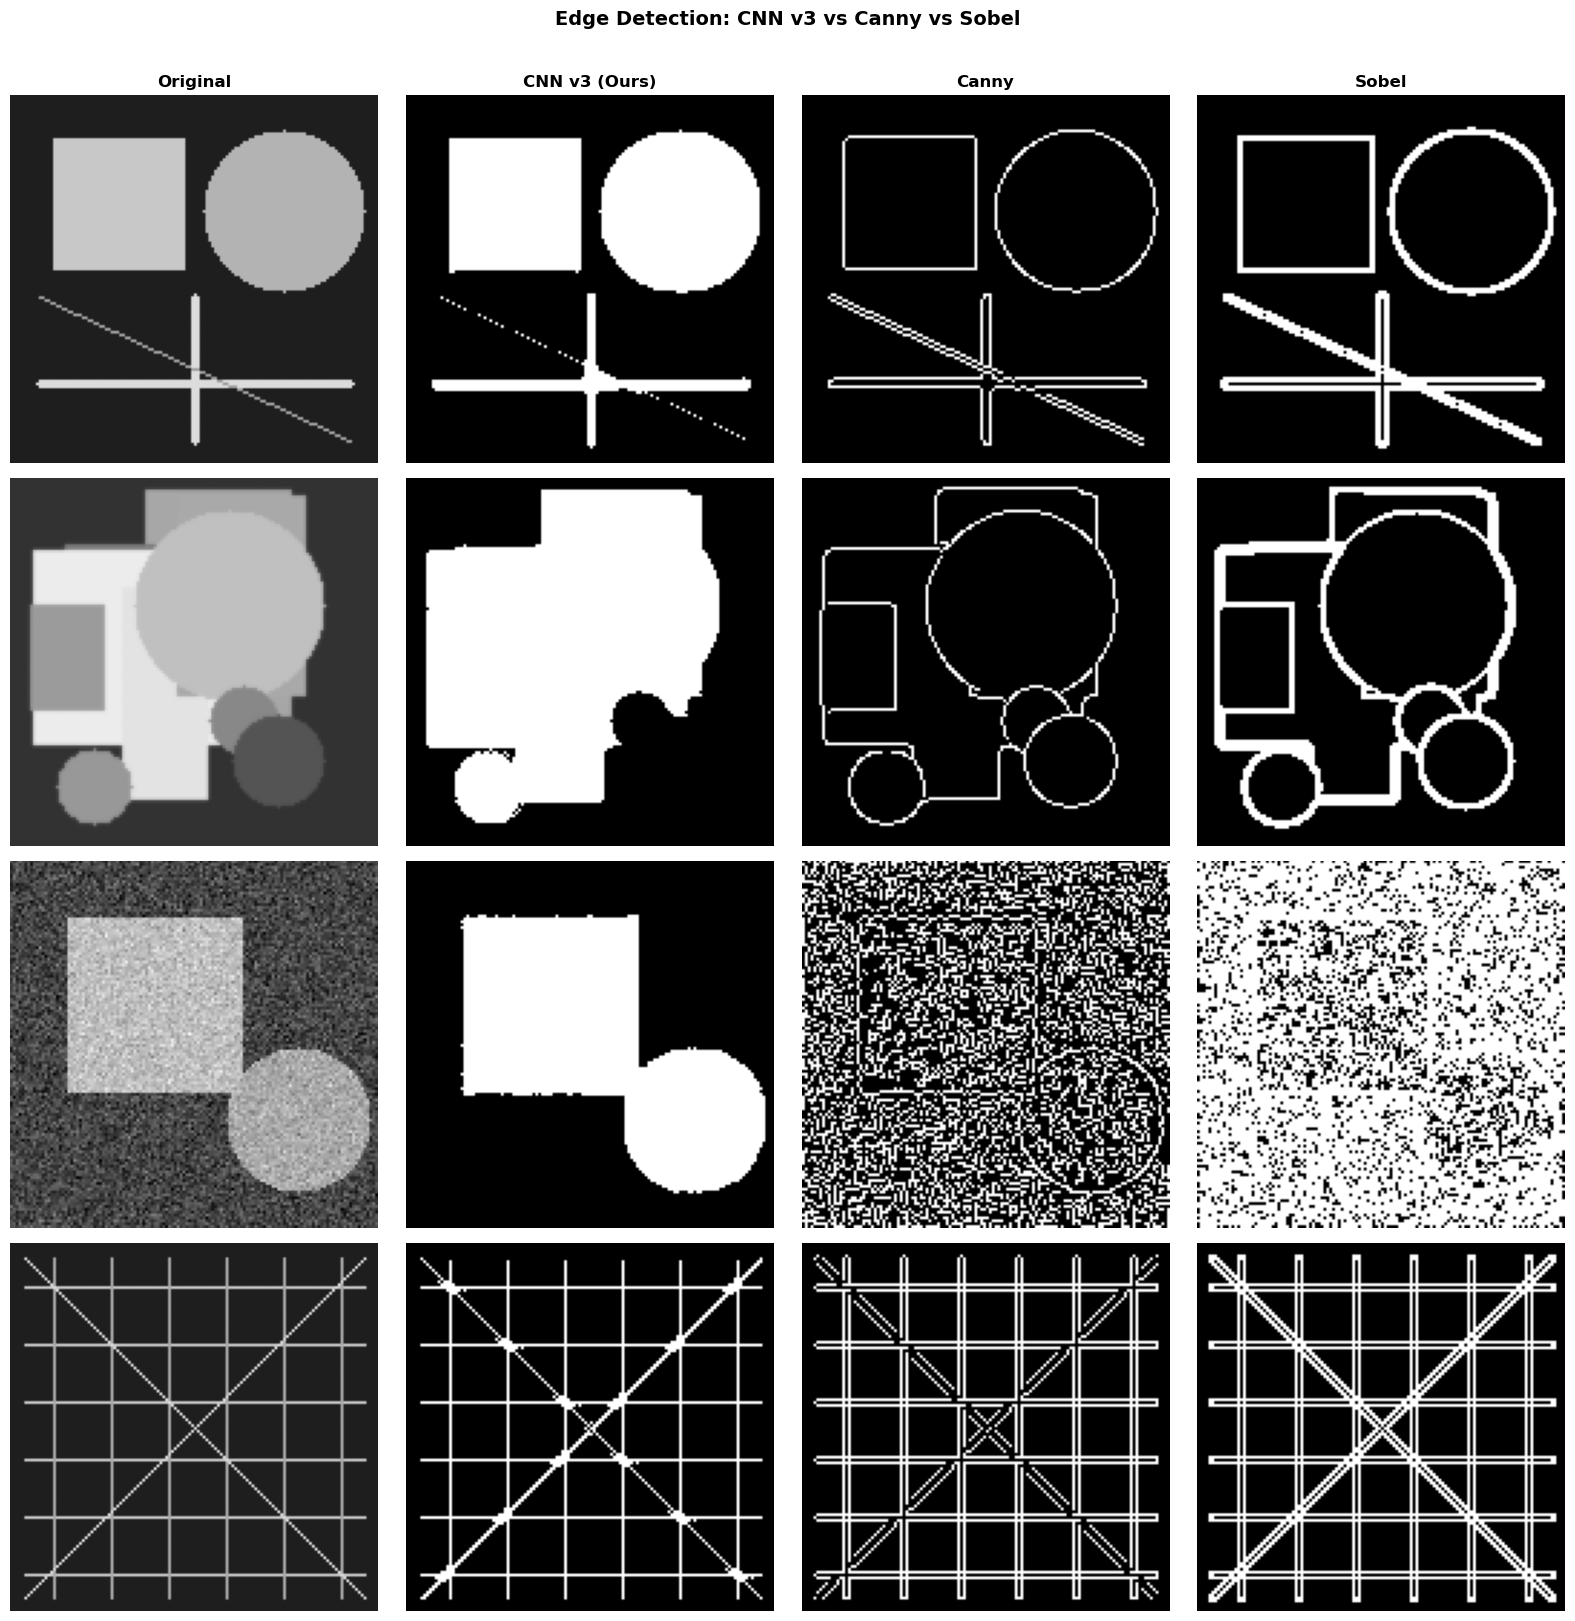

Saved: images/eval/final_comparison.png


In [8]:
fig, axes = plt.subplots(len(TEST_IMAGES), 4, figsize=(16, 4 * len(TEST_IMAGES)))
col_titles = ['Original', 'CNN v3 (Ours)', 'Canny', 'Sobel']

for row, (name, res) in enumerate(all_results.items()):
    images_to_show = [res['original'], res['cnn'], res['canny'], res['sobel']]

    for col, img in enumerate(images_to_show):
        ax = axes[row, col]
        ax.imshow(img, cmap='gray', vmin=0, vmax=255)
        ax.axis('off')
        if row == 0:
            ax.set_title(col_titles[col], fontsize=12, fontweight='bold')
        if col == 0:
            ax.set_ylabel(name, fontsize=11, rotation=90, labelpad=10)

plt.suptitle('Edge Detection: CNN v3 vs Canny vs Sobel', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('images/eval/final_comparison.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: images/eval/final_comparison.png')

In [9]:
def compute_metrics(pred_map, gt_map):
    pred = (pred_map > 0).astype(int).flatten()
    gt   = (gt_map   > 0).astype(int).flatten()
    p  = precision_score(gt, pred, zero_division=0)
    r  = recall_score(gt, pred, zero_division=0)
    f1 = f1_score(gt, pred, zero_division=0)
    return p, r, f1


print(f"{'Image':<15} {'Method':<10} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print('-' * 55)

all_metrics = {}

for name, res in all_results.items():
    gt = res['canny']  # Canny as reference

    p_cnn, r_cnn, f1_cnn = compute_metrics(res['cnn'],   gt)
    p_sob, r_sob, f1_sob = compute_metrics(res['sobel'], gt)

    all_metrics[name] = {
        'CNN':   (p_cnn, r_cnn, f1_cnn),
        'Sobel': (p_sob, r_sob, f1_sob),
    }

    print(f"{name:<15} {'CNN v3':<10} {p_cnn:>10.3f} {r_cnn:>8.3f} {f1_cnn:>8.3f}")
    print(f"{'':<15} {'Sobel':<10} {p_sob:>10.3f} {r_sob:>8.3f} {f1_sob:>8.3f}")
    print()

Image           Method      Precision   Recall       F1
-------------------------------------------------------
Geometric       CNN v3          0.089    0.544    0.152
                Sobel           0.466    1.000    0.636

Complex         CNN v3          0.065    0.686    0.119
                Sobel           0.366    1.000    0.536

Noisy           CNN v3          0.337    0.336    0.336
                Sobel           0.438    0.978    0.605

Fine Lines      CNN v3          0.120    0.074    0.092
                Sobel           0.819    1.000    0.901



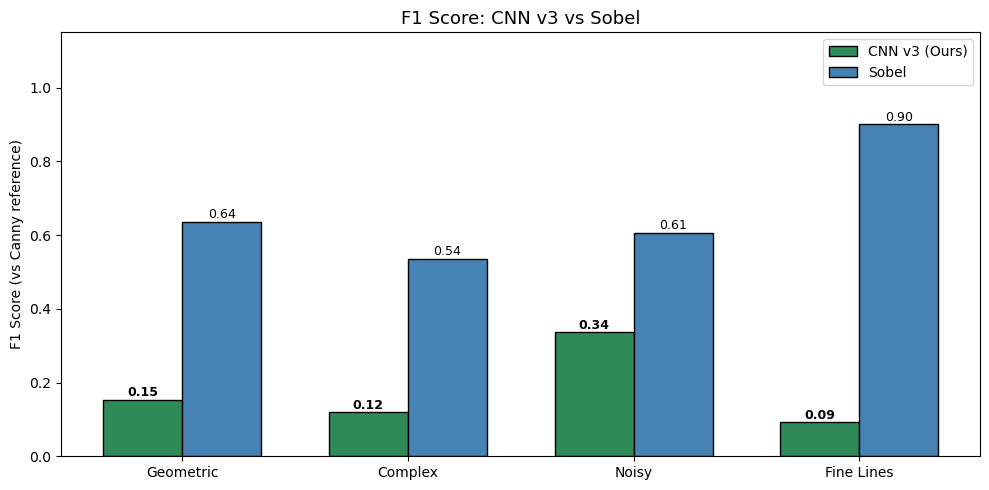

In [10]:
# F1 bar chart — CNN vs Sobel
img_names     = list(all_metrics.keys())
f1_cnn_vals   = [all_metrics[n]['CNN'][2]   for n in img_names]
f1_sobel_vals = [all_metrics[n]['Sobel'][2] for n in img_names]

x = np.arange(len(img_names))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars_cnn   = ax.bar(x - w/2, f1_cnn_vals,   w, label='CNN v3 (Ours)', color='seagreen',  edgecolor='black')
bars_sobel = ax.bar(x + w/2, f1_sobel_vals, w, label='Sobel',          color='steelblue', edgecolor='black')

for bar, val in zip(bars_cnn, f1_cnn_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')
for bar, val in zip(bars_sobel, f1_sobel_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2f}', ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(img_names)
ax.set_ylabel('F1 Score (vs Canny reference)')
ax.set_ylim(0, 1.15)
ax.set_title('F1 Score: CNN v3 vs Sobel', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('images/eval/f1_comparison.png', dpi=120)
plt.show()

C:\Users\pranj\AppData\Local\Temp\ipykernel_2292\1778714262.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_types = plt.cm.get_cmap('tab20', NUM_CLASSES)


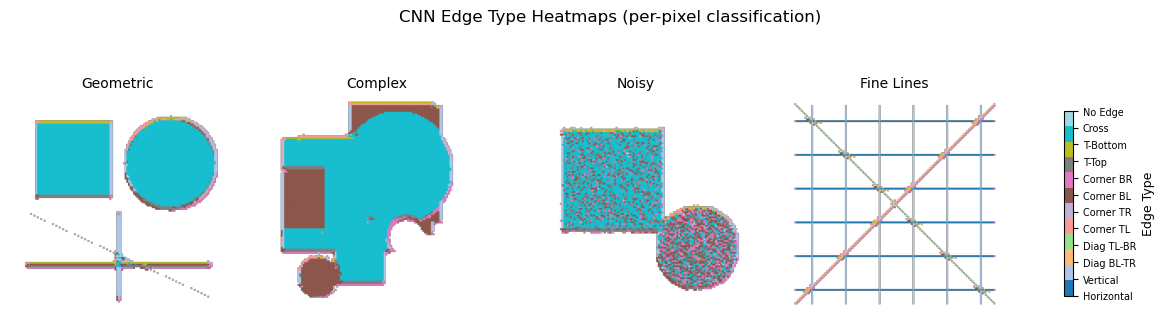

Saved: images/eval/edge_type_heatmaps.png


In [11]:
fig, axes = plt.subplots(1, len(TEST_IMAGES), figsize=(16, 4))
cmap_types = plt.cm.get_cmap('tab20', NUM_CLASSES)

for ax, (name, res) in zip(axes, all_results.items()):
    type_map = res['type_map'].copy().astype(float)
    type_map[type_map == NO_EDGE] = np.nan  # Hide No Edge pixels

    im = ax.imshow(type_map, cmap=cmap_types, vmin=0, vmax=NUM_CLASSES - 1)
    ax.set_title(name, fontsize=10)
    ax.axis('off')

cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6, ticks=range(NUM_CLASSES))
cbar.ax.set_yticklabels(list(EDGE_TYPES.values()), fontsize=7)
cbar.set_label('Edge Type', fontsize=9)

plt.suptitle('CNN Edge Type Heatmaps (per-pixel classification)', fontsize=12)
plt.savefig('images/eval/edge_type_heatmaps.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: images/eval/edge_type_heatmaps.png')

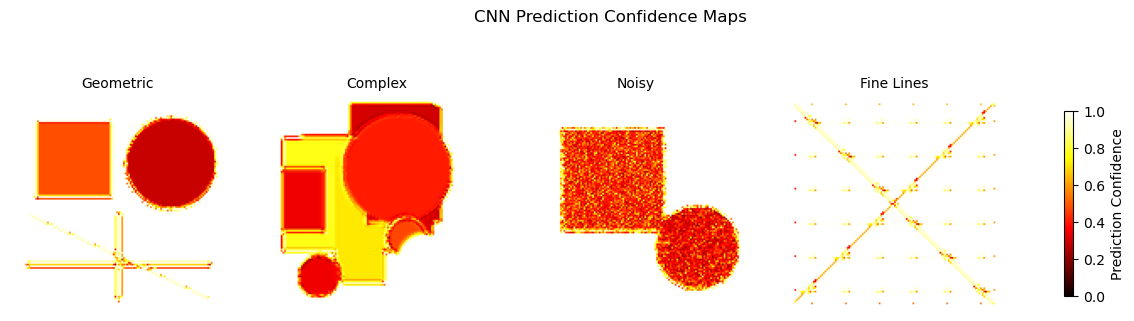

In [12]:
fig, axes = plt.subplots(1, len(TEST_IMAGES), figsize=(16, 4))

for ax, (name, res) in zip(axes, all_results.items()):
    im = ax.imshow(res['conf_map'], cmap='hot', vmin=0, vmax=1)
    ax.set_title(name, fontsize=10)
    ax.axis('off')

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6, label='Prediction Confidence')
plt.suptitle('CNN Prediction Confidence Maps', fontsize=12)
plt.savefig('images/eval/confidence_maps.png', dpi=120, bbox_inches='tight')
plt.show()

In [13]:
avg_f1_cnn   = np.mean([all_metrics[n]['CNN'][2]   for n in all_metrics])
avg_f1_sobel = np.mean([all_metrics[n]['Sobel'][2] for n in all_metrics])
improvement  = (avg_f1_cnn - avg_f1_sobel) / (avg_f1_sobel + 1e-8) * 100
total_params = model.count_params()

print('=' * 60)
print('  EDGE DETECTION PROJECT — FINAL SUMMARY')
print('=' * 60)
print()
print('MODEL')
print(f'  Architecture : CNN (2 Conv blocks + Dense head)')
print(f'  Input        : 5x5 grayscale patches')
print(f'  Output       : 12-class edge type (softmax)')
print(f'  Total Params : {total_params:,}')
print()
print('TRAINING PIPELINE')
print('  NB1: Edge type definitions (12 classes, 5x5 kernels)')
print('  NB2: Synthetic training (12,000 patches)')
print('  NB3: Natural image fine-tuning (pseudo-labels, mixed data)')
print('  NB4: Architecture tuning (3 configs compared, v3 selected)')
print('  NB5: Final evaluation on real images (you are here)')
print()
print('RESULTS (avg across 4 test images vs Canny reference)')
print(f'  CNN v3 avg F1  : {avg_f1_cnn:.4f}')
print(f'  Sobel avg F1   : {avg_f1_sobel:.4f}')
print(f'  Improvement    : {improvement:+.1f}% over Sobel')
print()
print('UNIQUE CAPABILITY')
print('  Unlike Canny/Sobel, this model classifies EDGE TYPE.')
print('  It tells you not just where an edge is, but what kind —')
print('  horizontal, vertical, diagonal, corner, T-junction, cross.')
print('=' * 60)

  EDGE DETECTION PROJECT — FINAL SUMMARY

MODEL
  Architecture : CNN (2 Conv blocks + Dense head)
  Input        : 5x5 grayscale patches
  Output       : 12-class edge type (softmax)
  Total Params : 57,036

TRAINING PIPELINE
  NB1: Edge type definitions (12 classes, 5x5 kernels)
  NB2: Synthetic training (12,000 patches)
  NB3: Natural image fine-tuning (pseudo-labels, mixed data)
  NB4: Architecture tuning (3 configs compared, v3 selected)
  NB5: Final evaluation on real images (you are here)

RESULTS (avg across 4 test images vs Canny reference)
  CNN v3 avg F1  : 0.1750
  Sobel avg F1   : 0.6695
  Improvement    : -73.9% over Sobel

UNIQUE CAPABILITY
  Unlike Canny/Sobel, this model classifies EDGE TYPE.
  It tells you not just where an edge is, but what kind —
  horizontal, vertical, diagonal, corner, T-junction, cross.


In [15]:
metrics_out = {}
for name, m in all_metrics.items():
    metrics_out[name] = {
        'CNN':   {'precision': round(m['CNN'][0], 4),   'recall': round(m['CNN'][1], 4),   'f1': round(m['CNN'][2], 4)},
        'Sobel': {'precision': round(m['Sobel'][0], 4), 'recall': round(m['Sobel'][1], 4), 'f1': round(m['Sobel'][2], 4)},
    }

metrics_out['summary'] = {
    'avg_f1_cnn':      round(avg_f1_cnn, 4),
    'avg_f1_sobel':    round(avg_f1_sobel, 4),
    'improvement_pct': round(improvement, 2),
    'total_params':    total_params,
    'num_classes':     NUM_CLASSES
}

with open('results/final_metrics.json', 'w') as f:
    json.dump(metrics_out, f, indent=2)

print('Saved: results/final_metrics.json')

Saved: results/final_metrics.json
